# Automated Business Report Generator using Data Analytics and Generative AI
##Project by Abhirami T
## Introduction
Businesses generate large volumes of transactional data daily.
Extracting meaningful insights from raw data requires analytical skills and time.

This project aims to automate business analysis using:
- Data Analytics
- Machine Learning
- Generative AI concepts

The system analyzes sales data and automatically generates a business report including executive summaries, insights, and recommendations.

## Objectives
- Perform business data analysis
- Visualize trends and performance
- Predict sales using Machine Learning
- Automatically generate business insights using Generative AI


This project builds an automated system that analyzes sales data
and generates AI-based business reports to support decision making.

In [ ]:
# Install required libraries
!pip install pandas matplotlib seaborn scikit-learn

##Importing Required Libraries

In this section, we import Python libraries necessary for data manipulation, visualization, and machine learning. These libraries help process business data, create visual insights, and build predictive models.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

##Loading the Dataset

In this step, the retail sales dataset is loaded into the notebook. The dataset contains sales transaction records including order dates, regions, product categories, sales values, discounts, and profits.

## Dataset Description

Dataset Used: Sample Superstore Dataset

This dataset contains retail business transaction data including:
- Order Date
- Region
- Category
- Sales
- Profit
- Quantity
- Discount

The dataset is used to analyze business performance and generate automated reports.

In [ ]:
from google.colab import files
upload = files.upload()

Saving SampleSuperstore.csv to SampleSuperstore.csv


In [ ]:
# Load dataset
df = pd.read_csv("SampleSuperstore.csv", encoding='latin1')

# Display first rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


##Understanding the Dataset

We inspect the dataset to understand its structure, data types, summary statistics, and potential missing values. This step helps evaluate the quality of the data before performing analysis.

In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
# Dataset size
df.shape

(9994, 21)

In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


##Date Feature Engineering

The Order Date column is converted to datetime format. This enables time-based analysis such as identifying yearly sales trends.

In [ ]:
# Convert Order Date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Verify conversion
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


## Exploratory Data Analysis

In this section, we analyze business performance using:
- Total sales and profit
- Regional performance
- Category profitability

In [ ]:
# Calculate total business performance
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217


##Sales Analysis by Region

This visualization shows total sales across different regions, helping identify top-performing and underperforming markets.

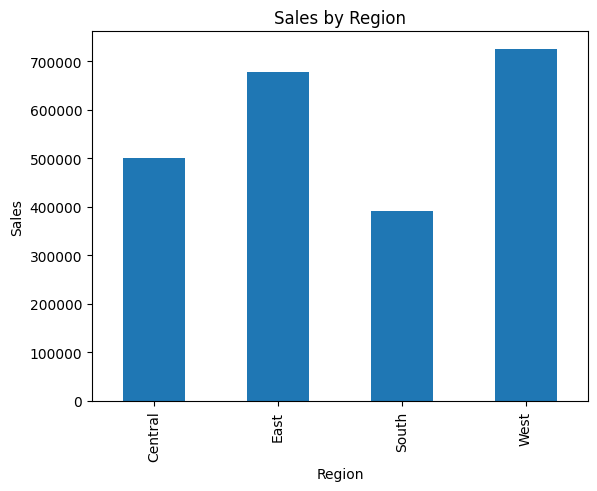

In [ ]:
# Group sales by region
region_sales = df.groupby('Region')['Sales'].sum()

# Plot graph
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

##Profit Analysis by Product Category

This analysis helps identify which product categories generate the highest profit.

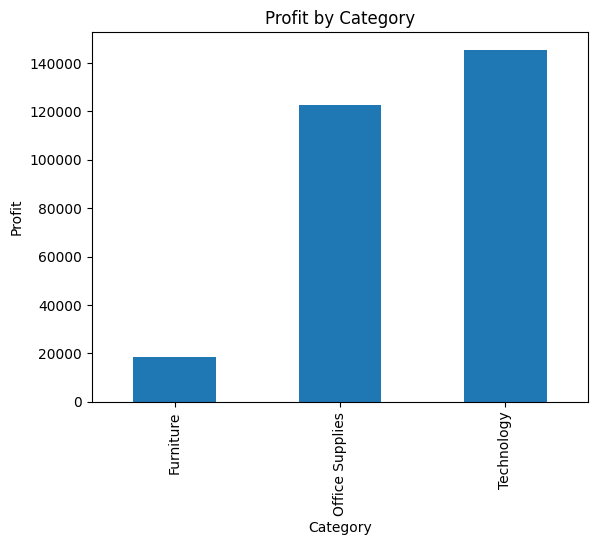

In [ ]:
# Profit by category
category_profit = df.groupby('Category')['Profit'].sum()

category_profit.plot(kind='bar')

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

##Sales Trend Analysis

This visualization shows how total sales change over time. It helps identify growth patterns and seasonal trends.

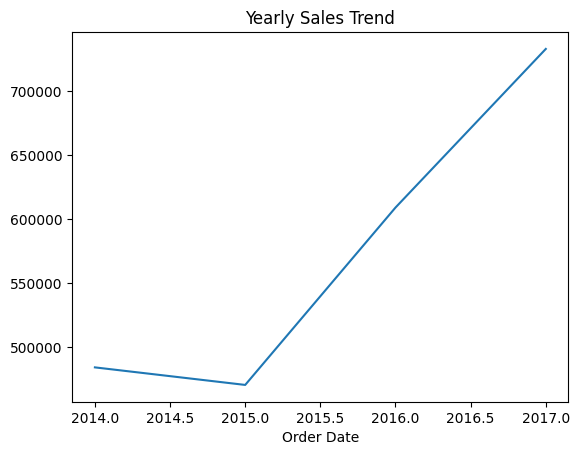

In [ ]:
# Sales trend over time
df.groupby(df['Order Date'].dt.year)['Sales'].sum().plot()
plt.title("Yearly Sales Trend")
plt.show()

##Discount vs Profit Analysis

This visualization explores the relationship between product discounts and profitability.

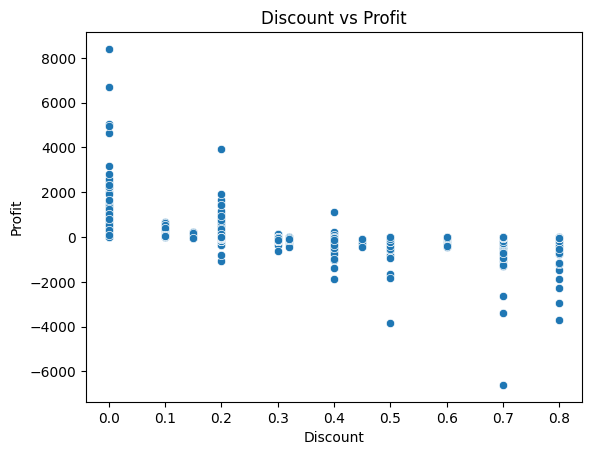

In [ ]:
#Discount vs Profit
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()

### Insight
Higher discounts tend to reduce profitability,
indicating pricing strategy importance.

##Machine Learning Model Development

A Linear Regression model is used to predict sales based on quantity and discount values. The dataset is split into training and testing sets to evaluate model performance.

In [ ]:
# Features and target
X = df[['Quantity', 'Discount']]
y = df['Sales']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

LinearRegression()

##Model Evaluation

The trained model is evaluated using Mean Squared Error (MSE), which measures the difference between predicted and actual sales values.

In [ ]:
# Predict sales
predictions = model.predict(X_test)

predictions[:5]

array([232.16210057, 126.68161285, 152.42850805, 166.54840911,
       179.42185671])

In [ ]:
# Evaluate model performance
mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 569282.568307617


##Generative AI Business Report

Generative AI concepts are applied to transform analytical results into human-readable business insights. The system generates an automated report summarizing key findings and recommendations.

In [ ]:
# Prepare analytical summary
summary = f"""
Total Sales: {total_sales}
Total Profit: {total_profit}
Top Region: {region_sales.idxmax()}
Most Profitable Category: {category_profit.idxmax()}
"""

print(summary)


Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Top Region: West
Most Profitable Category: Technology



In [ ]:
# Simulated Generative AI output

report = f"""
================ BUSINESS REPORT ================

EXECUTIVE SUMMARY:
The company achieved total sales of {total_sales:.2f}
and generated an overall profit of {total_profit:.2f}.

KEY FINDINGS:
- Highest performing region: {region_sales.idxmax()}
- Most profitable category: {category_profit.idxmax()}

RECOMMENDATIONS:
- Increase marketing efforts in high-performing regions.
- Optimize pricing strategies for lower-profit categories.
- Monitor discount levels to maintain profitability.

=================================================
"""

print(report)


================ BUSINESS REPORT ================

EXECUTIVE SUMMARY:
The company achieved total sales of 2297200.86
and generated an overall profit of 286397.02.

KEY FINDINGS:
- Highest performing region: West
- Most profitable category: Technology

RECOMMENDATIONS:
- Increase marketing efforts in high-performing regions.
- Optimize pricing strategies for lower-profit categories.
- Monitor discount levels to maintain profitability.




## Methodology
1. Data preprocessing using Pandas
2. Exploratory Data Analysis
3. Machine Learning prediction
4. Generative AI-based report generation

## Challenges Faced
- Data formatting issues
- Feature selection for prediction

## Future Scope
- Real-time dashboard integration
- Chatbot-based business assistant
- Automated decision-making systems

## Conclusion

The project successfully demonstrates how data analytics,
machine learning, and Generative AI can be integrated to
automate business reporting.

The system reduces manual analysis effort and provides
quick, understandable insights for business decision-making.